## Wizualizacja embeddingu obrazów i tekstów

In [1]:
import os
import sys

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import random
from pathlib import Path
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from datasets.coco_dataset import COCO_Dataset
from models.inferencer import ModelInferencer


c:\Users\kubas\nn-1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
DATA_DIR = Path("../data/coco") 
CHECKPOINT_PATH = Path("../checkpoint/final_model_model_best.pth") 

In [24]:
dataset = COCO_Dataset(
    image_dir=DATA_DIR / "val2017",
    annotation_file=DATA_DIR / "annotations" / "captions_val2017.json",
    img_transform=None 
)

# Losowanie próbki

Wybieramy losową próbkę danych ze zbioru walidacyjnego i zapisujemy obrazy oraz odpowiadające im podpisy w tablicach (dla każdego obrazu wybieramy jeden podpis)

In [49]:
N = 100
indices = random.sample(range(len(dataset)), N)

image_paths = []
texts = []

for idx in indices:
    img_path, captions = dataset.samples[idx]
    image_paths.append(img_path)
    texts.append(captions[0]) 

# Wczytanie modelu

Wczytujemy wytrenowany model z zapisanego pliku z wagami

In [50]:
inferencer = ModelInferencer(CHECKPOINT_PATH)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11944.11it/s]


Załadowano: final_model | epoch 20 | val_loss 1.2587


# Embedding

Dla danych tekstowych oraz obrazów tworzymy embeddingi z użyciem wytrenowanego modelu

In [51]:
image_embeds = inferencer.embed_image(image_paths)
text_embeds = inferencer.embed_text(texts)

image_embeds = image_embeds.numpy()
text_embeds = text_embeds.numpy()

# Złączenie wektorów

Łączymy wektory zawierające kodowanie obrazów i tekstu

In [52]:
combined = np.vstack([image_embeds, text_embeds])

# PCA + t-SNE oraz UMAP

In [53]:
pca = PCA(n_components=50, svd_solver='full')
combined_pca_50 = pca.fit_transform(combined)

total_variance = pca.explained_variance_ratio_.sum()
print("Variance explained (after PCA only): ", total_variance)

tsne = TSNE(n_components=2, random_state=42)
combined_tsne = tsne.fit_transform(combined_pca_50)

Variance explained (after PCA only):  0.82693994


# Podział wektorów

Dzielimy z powrotem na wektory zawierające kodowanie obrazów i tekstu

In [54]:
def split_embeddings(combined_2d: np.ndarray, n: int) -> Tuple[np.ndarray, np.ndarray]:
    return combined_2d[:n], combined_2d[n:]

img_tsne, txt_tsne = split_embeddings(combined_tsne, N)

#  Rysowanie wykresów

Definiujemy funkcję do rysowania wykresów i tworzymy wykresy dla danych przetworzonych za pomocą PCA i t-SNE oraz UMAP

In [55]:
from typing import List, Optional

from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from PIL import Image


def plot_embeddings_extended(
    img_2d: np.ndarray,
    txt_2d: np.ndarray,
    title: str,

    image_paths: Optional[List[str]] = None,
    texts: Optional[List[str]] = None,

    show_images: bool = False,
    show_texts: bool = False,

    max_samples: Optional[int] = None,
) -> None:
    plt.figure(figsize=(10, 8))
    ax = plt.gca()

    N = len(img_2d)
    if max_samples is not None:
        N = min(N, max_samples)

    img_2d = img_2d[:N]
    txt_2d = txt_2d[:N]

    if image_paths is not None:
        image_paths = image_paths[:N]

    if texts is not None:
        texts = texts[:N]

    ax.scatter(img_2d[:, 0], img_2d[:, 1], alpha=0.8, label="Images")
    ax.scatter(txt_2d[:, 0], txt_2d[:, 1], alpha=0.8, label="Text")

    for i in range(N):
        ax.plot(
            [img_2d[i, 0], txt_2d[i, 0]],
            [img_2d[i, 1], txt_2d[i, 1]],
            color="gray",
            alpha=0.4
        )

    if show_images and image_paths is not None:
        for i in range(N):
            try:
                img = Image.open(image_paths[i]).convert("RGB")
                img.thumbnail((32, 32))

                ab = AnnotationBbox(
                    OffsetImage(img, zoom=1),
                    (img_2d[i, 0], img_2d[i, 1]),
                    xybox=(15, 15), 
                    boxcoords="offset points",
                    frameon=False
                    )
                ax.add_artist(ab)

            except Exception as e:
                print(f"Error loading image {image_paths[i]}: {e}")

    if show_texts and texts is not None:
        for i in range(N):
            short_text = texts[i][:10] + "..." if len(texts[i]) > 10 else texts[i]

            ax.text(
                txt_2d[i, 0],
                txt_2d[i, 1],
                short_text,
                fontsize=8,
                alpha=0.8
            )

    ax.legend()
    ax.set_title(title)
    plt.show()

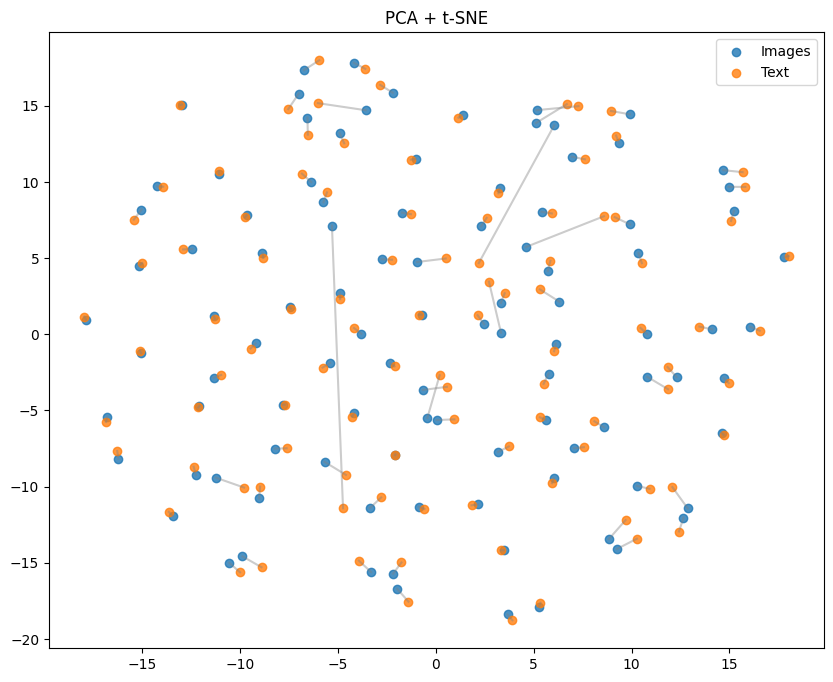

In [56]:
plot_embeddings_extended(img_tsne, txt_tsne, "PCA + t-SNE", None, None, False, False)

In [57]:
image_paths = []
texts = []

for idx in indices:
    img_path, captions = dataset.samples[idx]

    image_paths.append(str(img_path))
    texts.append(random.choice(captions))

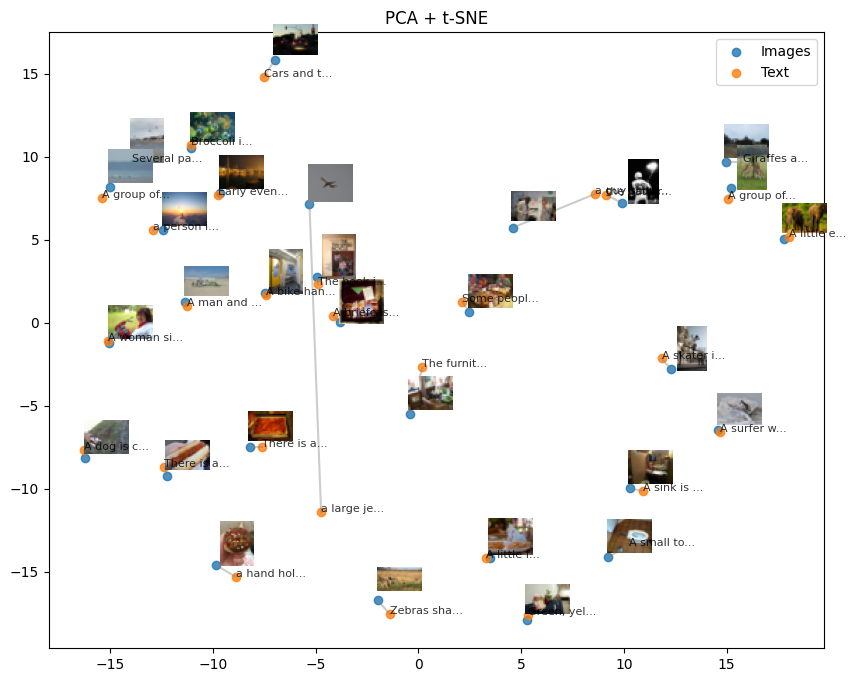

In [58]:
plot_embeddings_extended(img_tsne, txt_tsne, "PCA + t-SNE", image_paths, texts, True, True, 30)

In [59]:
def show_worst_pairs(
    img_2d: np.ndarray,
    txt_2d: np.ndarray,
    image_paths: List[str],
    texts: List[str],
    k: int = 5,
) -> None:
    distances = np.linalg.norm(img_2d - txt_2d, axis=1)

    worst_indices = np.argsort(distances)[-k:][::-1]

    print("Top-k worst pairs:\n")

    for rank, idx in enumerate(worst_indices, start=1):
        dist = distances[idx]

        print(f"Rank {rank}")
        print(f"Index: {idx}")
        print(f"Distance: {dist:.4f}")
        print(f"Text: {texts[idx]}")
        print(f"Image coords: {img_2d[idx]}")
        print(f"Text coords: {txt_2d[idx]}")
        print("-" * 50)

        try:
            img = Image.open(image_paths[idx]).convert("RGB")

            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"Rank {rank} | dist={dist:.4f}")
            plt.show()

        except Exception as e:
            print(f"Error loading image {image_paths[idx]}: {e}")

Top-k worst pairs:

Rank 1
Index: 1
Distance: 18.5527
Text: a large jet airplane flying in the sky
Image coords: [-5.2992234  7.127129 ]
Text coords: [ -4.7338033 -11.416954 ]
--------------------------------------------------


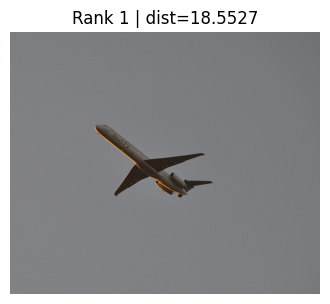

Rank 2
Index: 88
Distance: 9.8193
Text: A tennis player anticipating the ball on the court.
Image coords: [ 6.045408 13.710549]
Text coords: [2.1980064 4.676432 ]
--------------------------------------------------


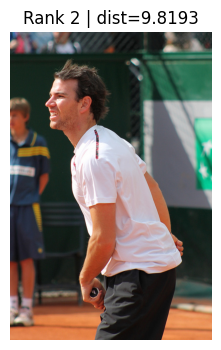

Rank 3
Index: 4
Distance: 4.4725
Text: a guy showing another guy a base ball bat
Image coords: [4.600487 5.729319]
Text coords: [8.590104 7.750728]
--------------------------------------------------


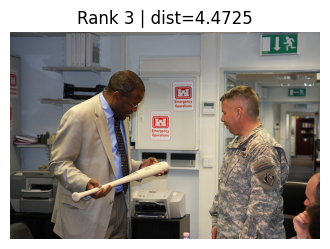

Rank 4
Index: 96
Distance: 3.4013
Text: two people sitting at a table posing for a photo
Image coords: [3.3336504  0.10904963]
Text coords: [2.7195935 3.454428 ]
--------------------------------------------------


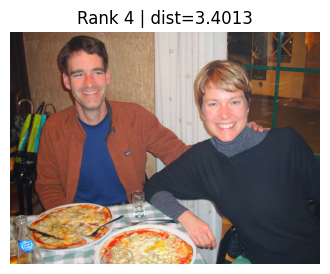

Rank 5
Index: 18
Distance: 2.8685
Text: The furniture is posed in the room with a sign that says do not touch. 
Image coords: [-0.426632 -5.484257]
Text coords: [ 0.20050113 -2.685116  ]
--------------------------------------------------


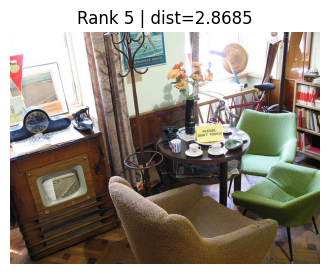

In [60]:
show_worst_pairs(img_tsne, txt_tsne, image_paths, texts, 5)